In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/market_stress_analysis.csv")

In [ ]:
print(df.isnull().sum())

Date             0
Nifty 50         0
Bank Nifty       0
Nifty Pharma     0
Nifty IT         0
Nifty Auto       0
Nifty FMCG       0
India_VIX        0
Gold             0
Crude_Oil        0
USD_INR          0
SP500            0
Repo_Rate        0
CPI_Inflation    0
Is_Stress        0
VIX_lag          1
Repo_lag         1
CPI_lag          1
USD_INR_lag      1
Gold_lag         1
Crude_Oil_lag    1
SP500_lag        1
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2987 entries, 0 to 2986
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2987 non-null   object 
 1   Nifty 50       2987 non-null   float64
 2   Bank Nifty     2987 non-null   float64
 3   Nifty Pharma   2987 non-null   float64
 4   Nifty IT       2987 non-null   float64
 5   Nifty Auto     2987 non-null   float64
 6   Nifty FMCG     2987 non-null   float64
 7   India_VIX      2987 non-null   float64
 8   Gold           2987 non-null   float64
 9   Crude_Oil      2987 non-null   float64
 10  USD_INR        2987 non-null   float64
 11  SP500          2987 non-null   float64
 12  Repo_Rate      2987 non-null   float64
 13  CPI_Inflation  2987 non-null   float64
 14  Is_Stress      2987 non-null   int64  
 15  VIX_lag        2986 non-null   float64
 16  Repo_lag       2986 non-null   float64
 17  CPI_lag        2986 non-null   float64
 18  USD_INR_

# **# EDA:**

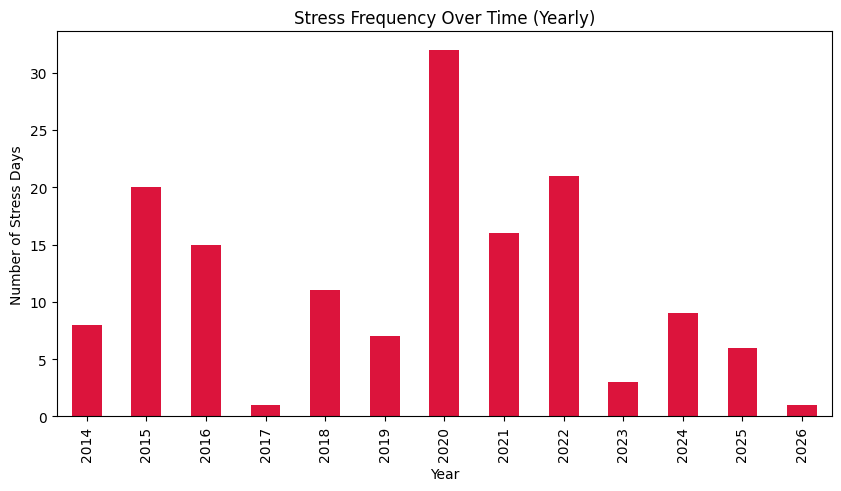

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("market_stress_analysis.csv")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Stress frequency over time
stress_counts = df.groupby(df['Date'].dt.year)['Is_Stress'].sum()

plt.figure(figsize=(10,5))
stress_counts.plot(kind='bar', color='crimson')
plt.title("Stress Frequency Over Time (Yearly)")
plt.xlabel("Year")
plt.ylabel("Number of Stress Days")
plt.show()

           India_VIX  Repo_Rate  CPI_Inflation
Is_Stress                                     
0          16.307892   6.022348       5.078932
1          23.037200   5.639000       5.391267


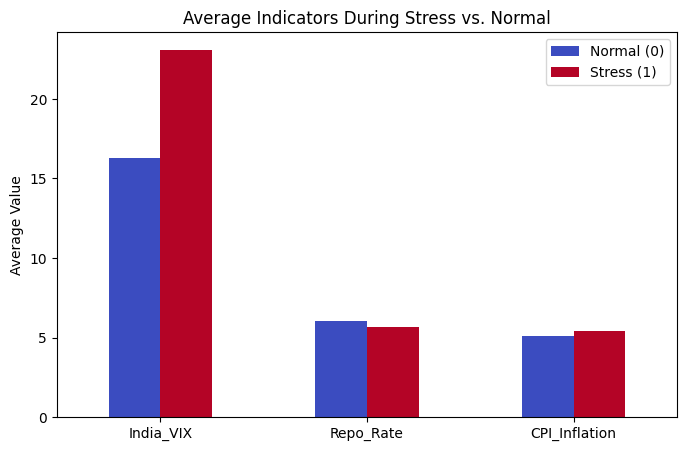

In [ ]:
# Group by stress vs. non-stress
avg_indicators = df.groupby("Is_Stress")[['India_VIX','Repo_Rate','CPI_Inflation']].mean()

print(avg_indicators)

# Plot comparison
avg_indicators.T.plot(kind='bar', figsize=(8,5), colormap="coolwarm")
plt.title("Average Indicators During Stress vs. Normal")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(["Normal (0)", "Stress (1)"])
plt.show()

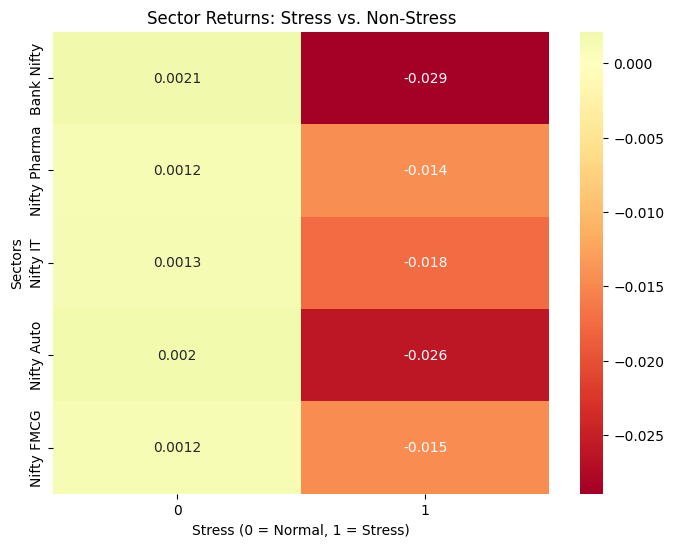

In [ ]:
# Calculate mean sector returns
sector_means = df.groupby("Is_Stress")[['Bank Nifty','Nifty Pharma','Nifty IT','Nifty Auto','Nifty FMCG']].mean()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(sector_means.T, annot=True, cmap="RdYlGn", center=0)
plt.title("Sector Returns: Stress vs. Non-Stress")
plt.xlabel("Stress (0 = Normal, 1 = Stress)")
plt.ylabel("Sectors")
plt.show()

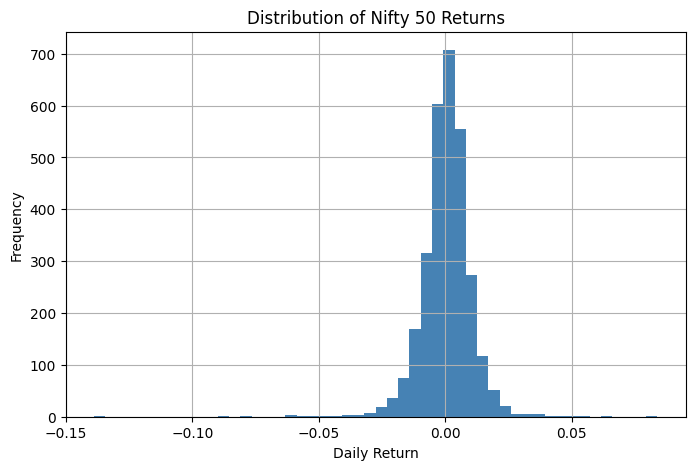

In [ ]:
df['Nifty 50'].hist(bins=50, figsize=(8,5), color='steelblue')
plt.title("Distribution of Nifty 50 Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

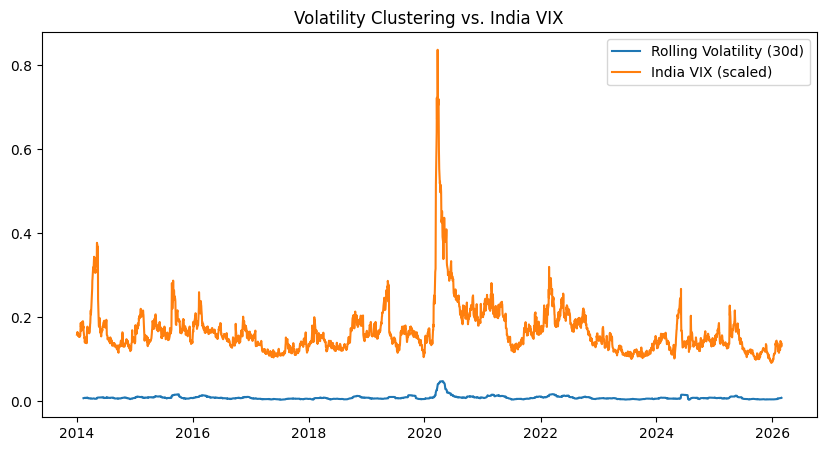

In [ ]:
df['rolling_vol'] = df['Nifty 50'].rolling(window=30).std()
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['rolling_vol'], label="Rolling Volatility (30d)")
plt.plot(df['Date'], df['India_VIX']/100, label="India VIX (scaled)")
plt.legend()
plt.title("Volatility Clustering vs. India VIX")
plt.show()

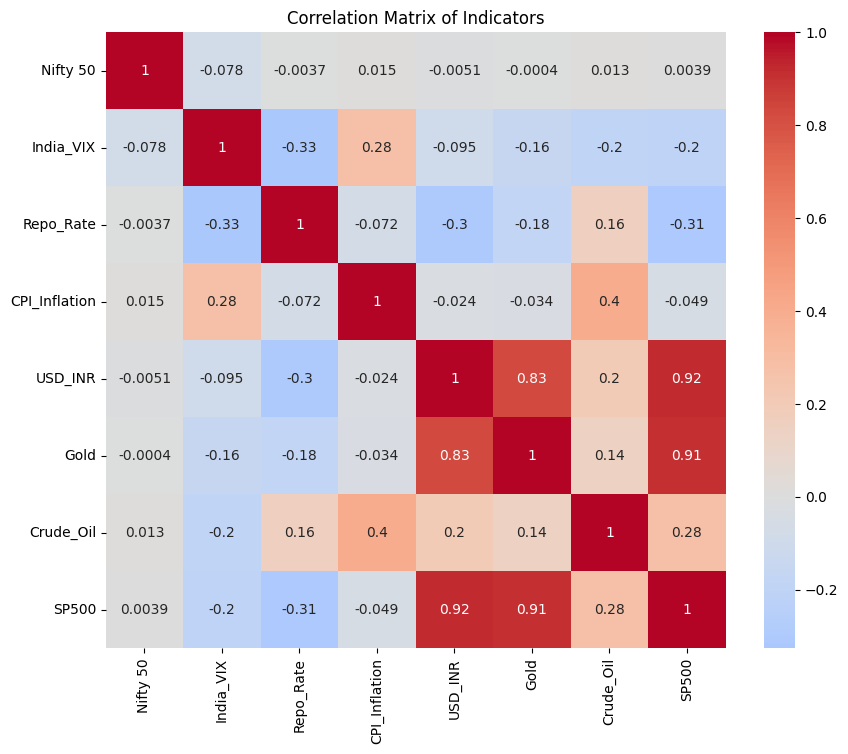

In [ ]:
corr = df[['Nifty 50','India_VIX','Repo_Rate','CPI_Inflation','USD_INR','Gold','Crude_Oil','SP500']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Indicators")
plt.show()

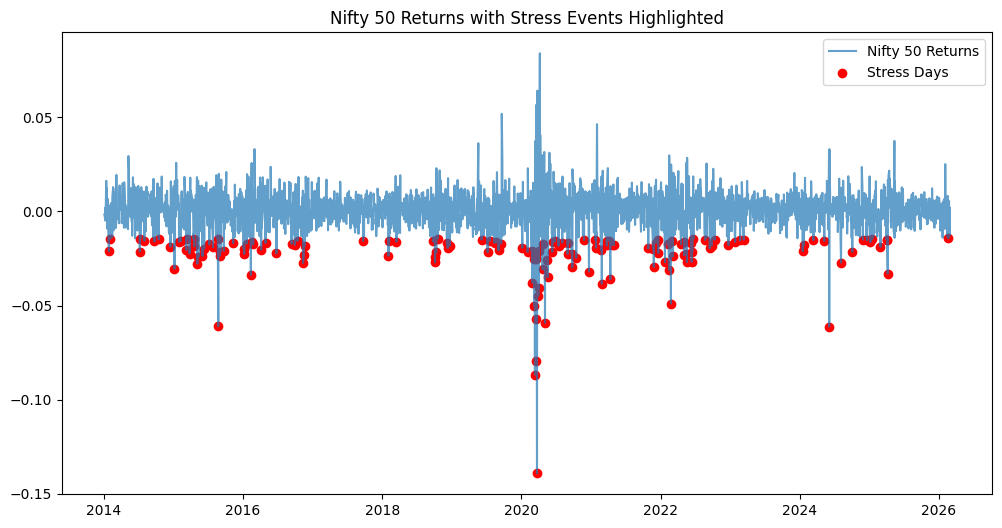

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Nifty 50'], label="Nifty 50 Returns", alpha=0.7)
plt.scatter(df['Date'][df['Is_Stress']==1], df['Nifty 50'][df['Is_Stress']==1], color='red', label="Stress Days")
plt.legend()
plt.title("Nifty 50 Returns with Stress Events Highlighted")
plt.show()

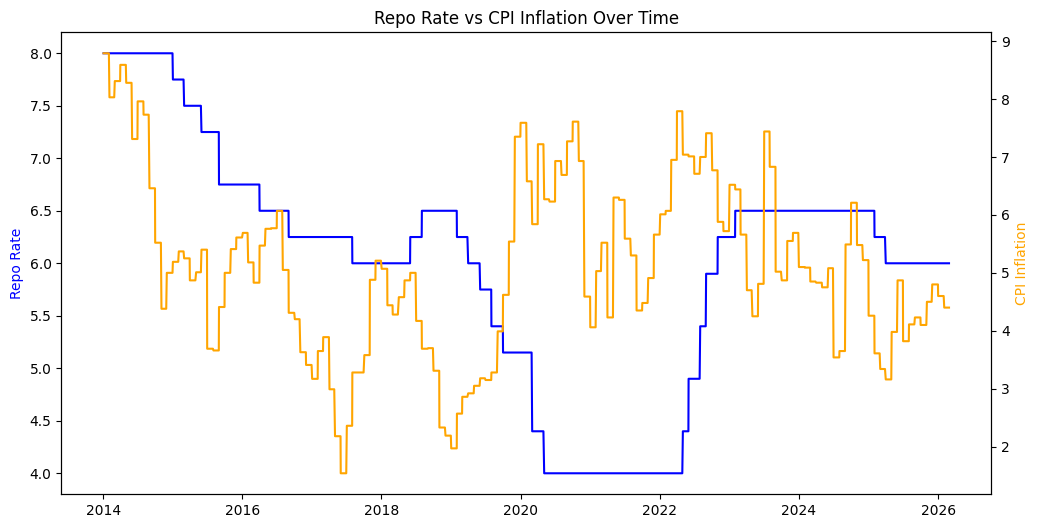

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df['Date'], df['Repo_Rate'], color='blue', label="Repo Rate")
ax1.set_ylabel("Repo Rate", color='blue')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['CPI_Inflation'], color='orange', label="CPI Inflation")
ax2.set_ylabel("CPI Inflation", color='orange')

plt.title("Repo Rate vs CPI Inflation Over Time")
plt.show()

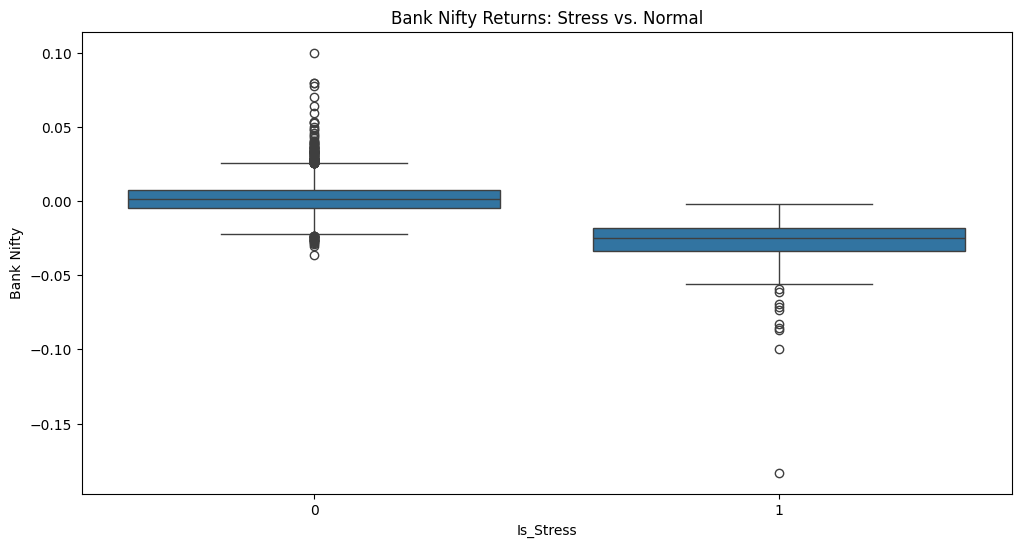

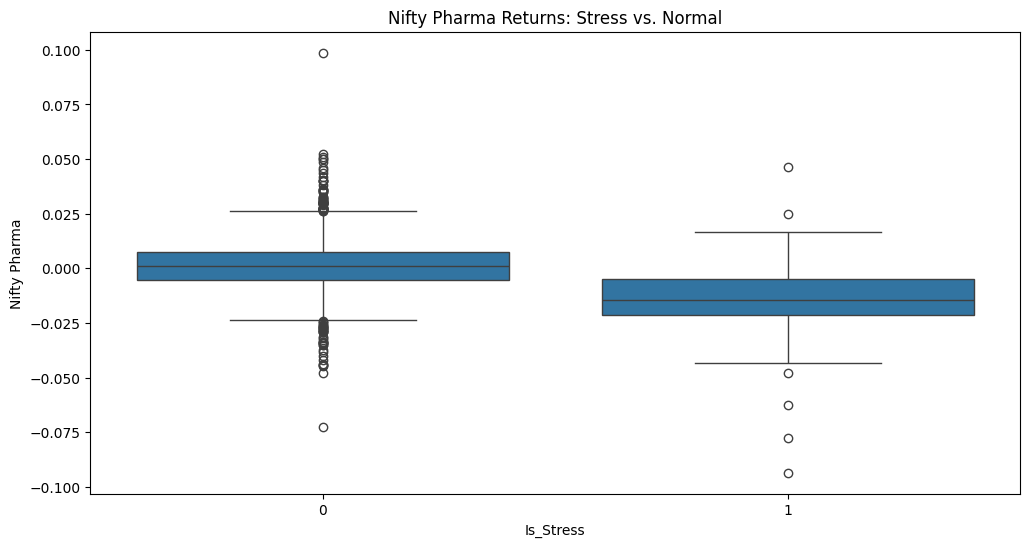

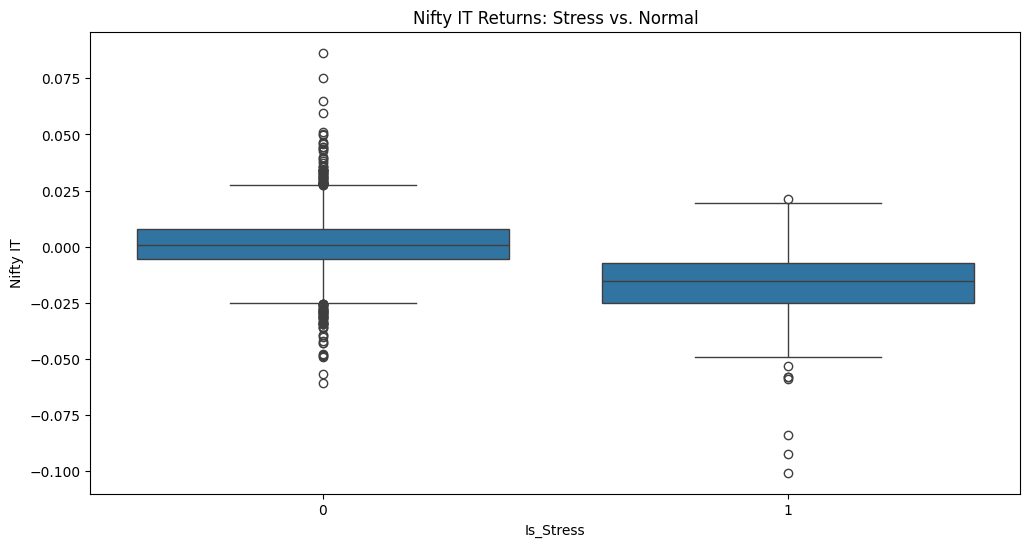

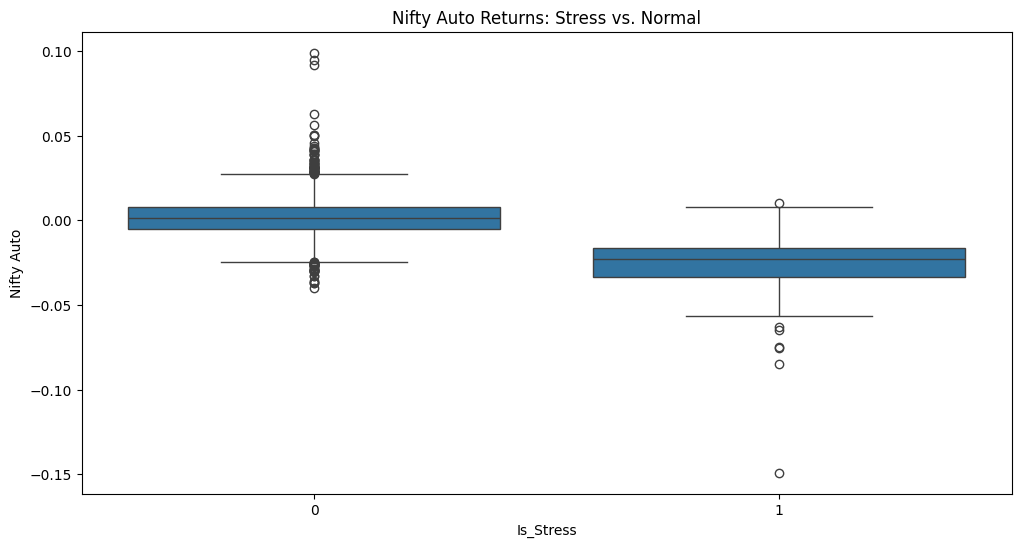

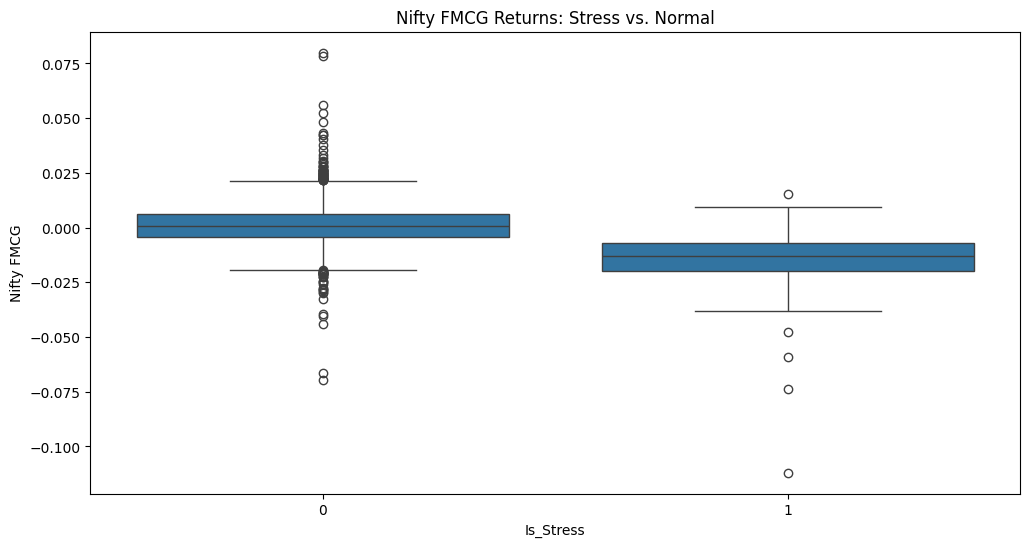

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Is_Stress", y="Bank Nifty", data=df)
plt.title("Bank Nifty Returns: Stress vs. Normal")
plt.show()

# Repeat for other sectors
for sector in ['Nifty Pharma','Nifty IT','Nifty Auto','Nifty FMCG']:
    plt.figure(figsize=(12,6))
    sns.boxplot(x="Is_Stress", y=sector, data=df)
    plt.title(f"{sector} Returns: Stress vs. Normal")
    plt.show()

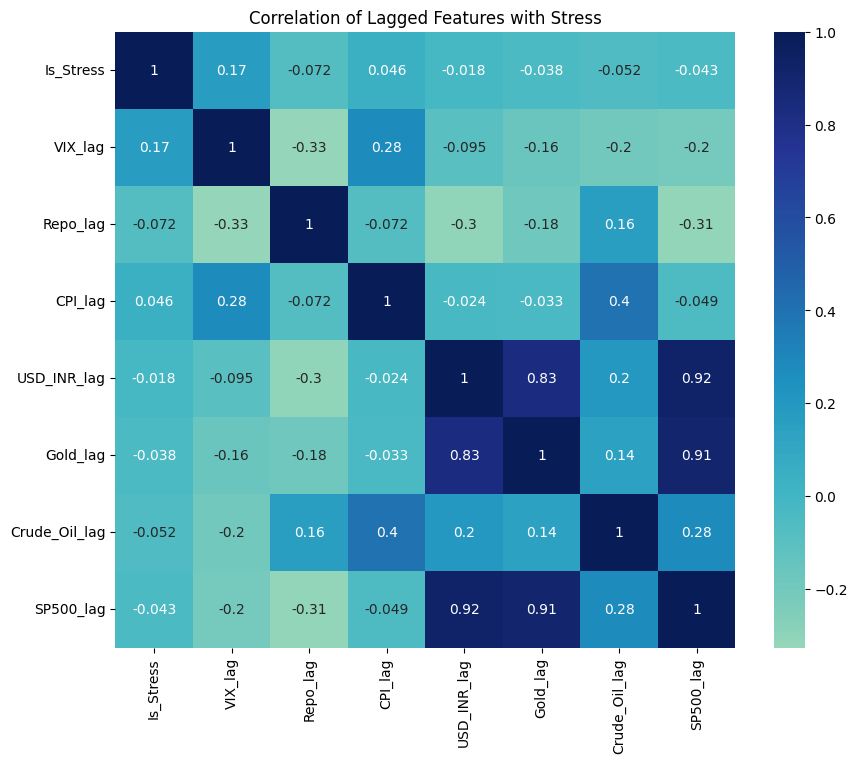

In [ ]:
lag_corr = df[['Is_Stress','VIX_lag','Repo_lag','CPI_lag','USD_INR_lag',
               'Gold_lag','Crude_Oil_lag','SP500_lag']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(lag_corr, annot=True, cmap="YlGnBu", center=0)
plt.title("Correlation of Lagged Features with Stress")
plt.show()

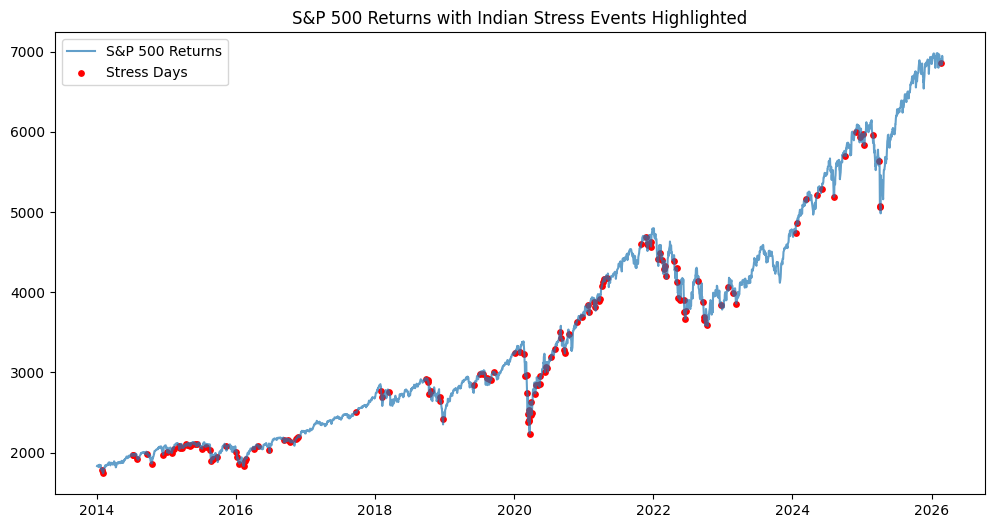

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['SP500'], label="S&P 500 Returns", alpha=0.7)
plt.scatter(df['Date'][df['Is_Stress']==1], df['SP500'][df['Is_Stress']==1],
            color='red', label="Stress Days", s=15)
plt.legend()
plt.title("S&P 500 Returns with Indian Stress Events Highlighted")
plt.show()

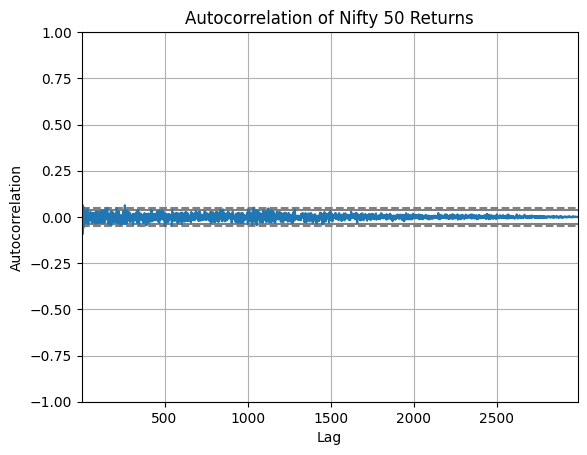

In [ ]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df['Nifty 50'])
plt.title("Autocorrelation of Nifty 50 Returns")
plt.show()

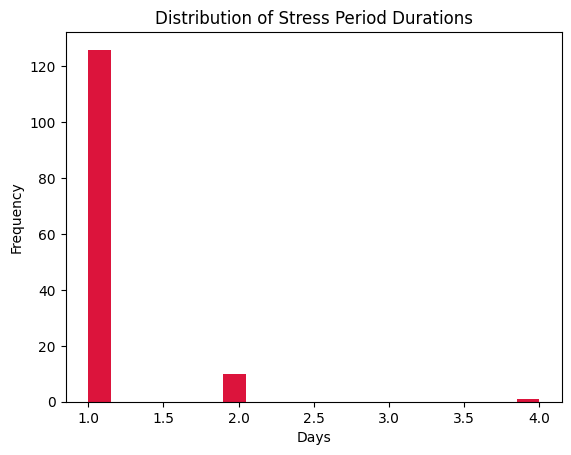

In [ ]:
df['stress_group'] = (df['Is_Stress'].diff().ne(0)).cumsum()
stress_lengths = df[df['Is_Stress']==1].groupby('stress_group').size()
plt.hist(stress_lengths, bins=20, color='crimson')
plt.title("Distribution of Stress Period Durations")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

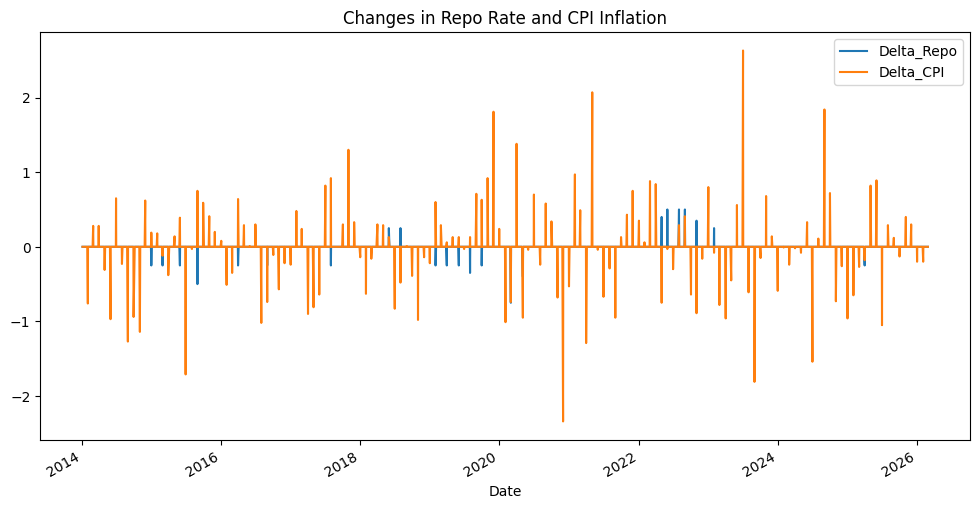

In [ ]:
df['Delta_Repo'] = df['Repo_Rate'].diff()
df['Delta_CPI'] = df['CPI_Inflation'].diff()
df[['Date','Delta_Repo','Delta_CPI']].plot(x='Date', figsize=(12,6))
plt.title("Changes in Repo Rate and CPI Inflation")
plt.show()

In [ ]:
stress_returns = df[df['Is_Stress']==1]['Nifty 50']
normal_returns = df[df['Is_Stress']==0]['Nifty 50']

print("Stress 5% quantile:", stress_returns.quantile(0.05))
print("Normal 5% quantile:", normal_returns.quantile(0.05))

Stress 5% quantile: -0.049639249999999996
Normal 5% quantile: -0.0102242


In [ ]:
import numpy as np
from scipy.stats import norm

# Example: Nifty 50 returns
returns = df['Nifty 50'].dropna()

# Parameters
mean_ret = returns.mean()
std_ret = returns.std()
confidence = 0.95

# VaR calculation (1-day horizon)
VaR_95 = norm.ppf(1-confidence, mean_ret, std_ret)
print("Parametric VaR (95%):", VaR_95)

Parametric VaR (95%): -0.016152101159689517


In [ ]:
confidence = 0.95
VaR_hist = np.percentile(returns, (1-confidence)*100)
print("Historical VaR (95%):", VaR_hist)

Historical VaR (95%): -0.014233199999999998


In [ ]:
simulations = np.random.normal(mean_ret, std_ret, 100000)
VaR_mc = np.percentile(simulations, (1-confidence)*100)
print("Monte Carlo VaR (95%):", VaR_mc)

Monte Carlo VaR (95%): -0.016179609803565954


In [ ]:
stress_returns = df[df['Is_Stress']==1]['Nifty 50']
normal_returns = df[df['Is_Stress']==0]['Nifty 50']

VaR_stress = np.percentile(stress_returns, 5)
VaR_normal = np.percentile(normal_returns, 5)

print("VaR (Stress, 95%):", VaR_stress)
print("VaR (Normal, 95%):", VaR_normal)

VaR (Stress, 95%): -0.049639249999999996
VaR (Normal, 95%): -0.0102242


In [ ]:
sectors = ['Bank Nifty','Nifty Pharma','Nifty IT','Nifty Auto','Nifty FMCG']

confidence = 0.95
for sector in sectors:
    returns = df[sector].dropna()
    VaR_hist = np.percentile(returns, (1-confidence)*100)
    print(f"{sector} Historical VaR (95%): {VaR_hist:.4f}")

Bank Nifty Historical VaR (95%): -0.0193
Nifty Pharma Historical VaR (95%): -0.0188
Nifty IT Historical VaR (95%): -0.0199
Nifty Auto Historical VaR (95%): -0.0197
Nifty FMCG Historical VaR (95%): -0.0150


In [ ]:
for sector in sectors:
    returns = df[sector].dropna()
    VaR_95 = np.percentile(returns, 5)
    CVaR_95 = returns[returns < VaR_95].mean()
    print(f"{sector} CVaR (95%): {CVaR_95:.4f}")

Bank Nifty CVaR (95%): -0.0320
Nifty Pharma CVaR (95%): -0.0272
Nifty IT CVaR (95%): -0.0310
Nifty Auto CVaR (95%): -0.0315
Nifty FMCG CVaR (95%): -0.0231


In [ ]:
for sector in sectors:
    stress_returns = df[df['Is_Stress']==1][sector]
    normal_returns = df[df['Is_Stress']==0][sector]
    print(f"{sector}: Stress Mean={stress_returns.mean():.4f}, Normal Mean={normal_returns.mean():.4f}")

Bank Nifty: Stress Mean=-0.0289, Normal Mean=0.0021
Nifty Pharma: Stress Mean=-0.0145, Normal Mean=0.0012
Nifty IT: Stress Mean=-0.0176, Normal Mean=0.0013
Nifty Auto: Stress Mean=-0.0262, Normal Mean=0.0020
Nifty FMCG: Stress Mean=-0.0147, Normal Mean=0.0012


In [ ]:
def max_drawdown(series):
    cum_returns = (1+series).cumprod()
    peak = cum_returns.cummax()
    drawdown = (cum_returns - peak) / peak
    return drawdown.min()

for sector in sectors:
    dd = max_drawdown(df[sector].dropna())
    print(f"{sector} Max Drawdown: {dd:.2%}")

Bank Nifty Max Drawdown: -50.35%
Nifty Pharma Max Drawdown: -58.31%
Nifty IT Max Drawdown: -36.58%
Nifty Auto Max Drawdown: -65.14%
Nifty FMCG Max Drawdown: -31.74%


In [ ]:
def max_drawdown(series):
    cum_returns = (1+series).cumprod()
    peak = cum_returns.cummax()
    drawdown = (cum_returns - peak) / peak
    return drawdown.min()

for sector in sectors:
    dd = max_drawdown(df[sector].dropna())
    print(f"{sector} Max Drawdown: {dd:.2%}")

Bank Nifty Max Drawdown: -50.35%
Nifty Pharma Max Drawdown: -58.31%
Nifty IT Max Drawdown: -36.58%
Nifty Auto Max Drawdown: -65.14%
Nifty FMCG Max Drawdown: -31.74%


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("market_stress_analysis.csv")

# Features and target
X = df[['India_VIX','Repo_Rate','CPI_Inflation','USD_INR','Gold','Crude_Oil','SP500',
        'VIX_lag','Repo_lag','CPI_lag','USD_INR_lag','Gold_lag','Crude_Oil_lag','SP500_lag']]
y = df['Is_Stress']

# Drop rows with any NaN values from X and y (assuming NaNs are aligned)
X = X.dropna()
y = y[X.index] # Ensure y corresponds to the cleaned X

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with column names for clarity
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Train model - Increased max_iter to ensure convergence, now with scaled data
log_reg = LogisticRegression(max_iter=5000) # Increased max_iter
log_reg.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

# Evaluation
print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       851
           1       0.78      0.16      0.26        45

    accuracy                           0.96       896
   macro avg       0.87      0.58      0.62       896
weighted avg       0.95      0.96      0.94       896

ROC-AUC: 0.9058623841232537
Confusion Matrix:
 [[849   2]
 [ 38   7]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Evaluation
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       851
           1       0.62      0.11      0.19        45

    accuracy                           0.95       896
   macro avg       0.79      0.55      0.58       896
weighted avg       0.94      0.95      0.94       896

ROC-AUC: 0.816346781564173
Confusion Matrix:
 [[848   3]
 [ 40   5]]


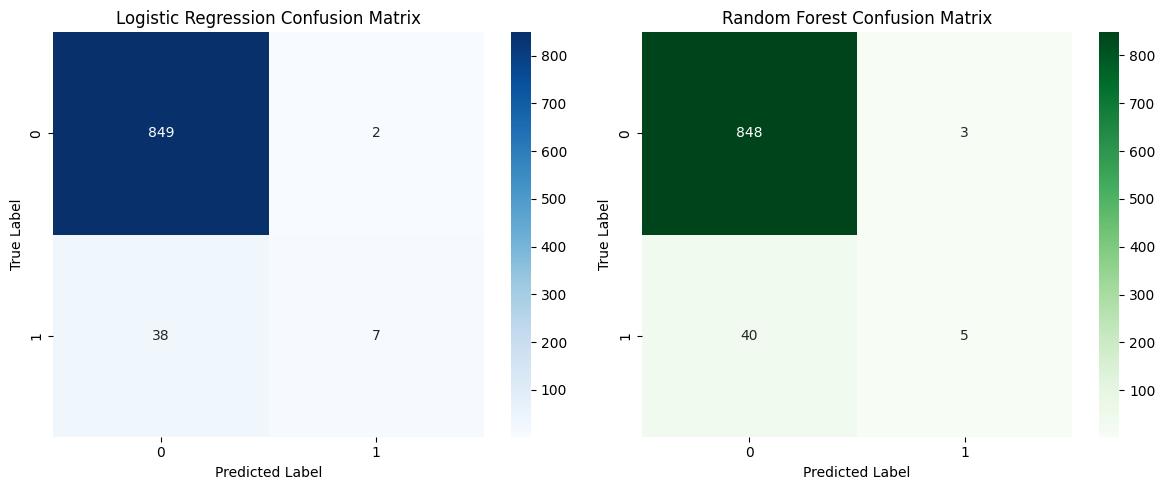

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get confusion matrices from previous execution (y_test, y_pred_lr, y_pred_rf should be available)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2166/2662815683.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")


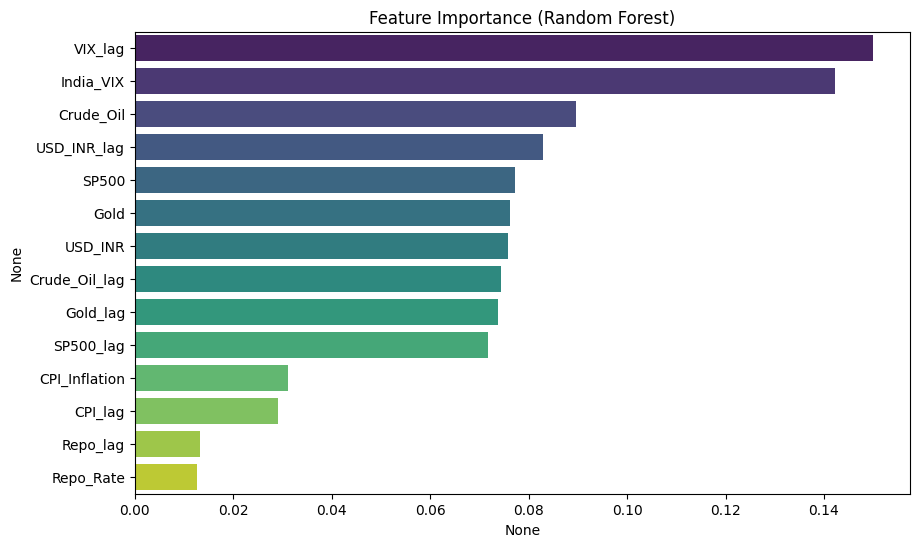

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       851
           1       0.50      0.07      0.12        45

    accuracy                           0.95       896
   macro avg       0.73      0.53      0.55       896
weighted avg       0.93      0.95      0.93       896

ROC-AUC: 0.8098707403055229


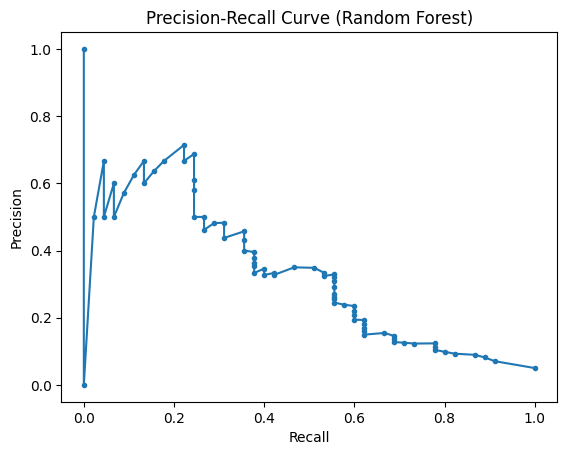

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

plt.plot(recall, precision, marker='.')
plt.title("Precision-Recall Curve (Random Forest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

/tmp/ipykernel_2166/3516173510.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['Stress_Prob'] = y_prob_rf


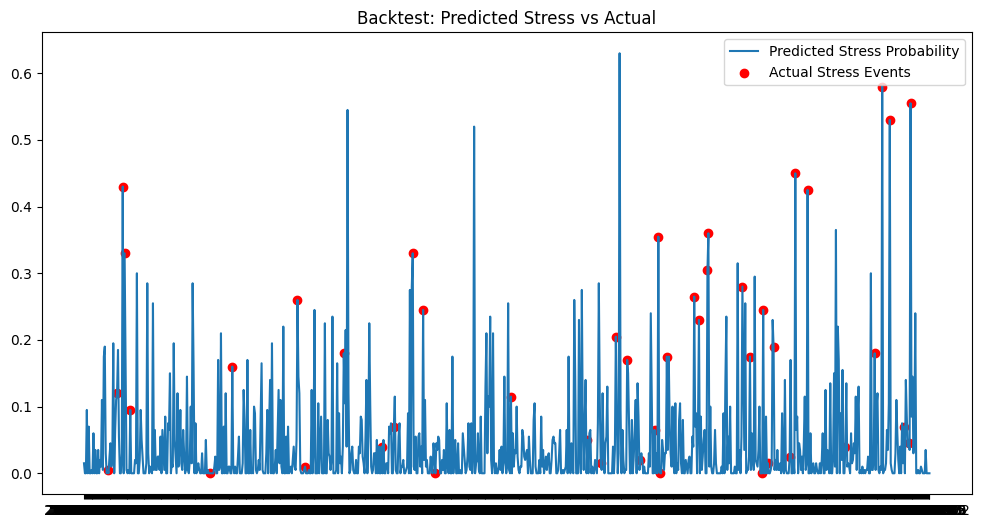

In [ ]:
df_test = df.iloc[y_test.index]  # align test set
df_test['Stress_Prob'] = y_prob_rf

plt.figure(figsize=(12,6))
plt.plot(df_test['Date'], df_test['Stress_Prob'], label="Predicted Stress Probability")
plt.scatter(df_test['Date'][df_test['Is_Stress']==1],
            df_test['Stress_Prob'][df_test['Is_Stress']==1],
            color='red', label="Actual Stress Events")
plt.legend()
plt.title("Backtest: Predicted Stress vs Actual")
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]), # imbalance handling
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost Results")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Results
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       851
           1       0.43      0.53      0.48        45

    accuracy                           0.94       896
   macro avg       0.70      0.75      0.72       896
weighted avg       0.95      0.94      0.94       896

ROC-AUC: 0.8487400443922183


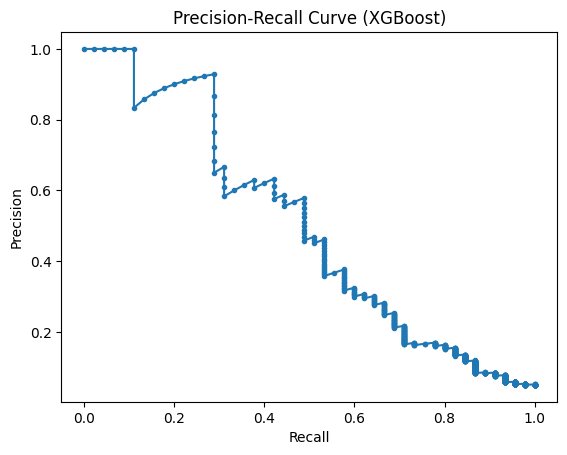

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.plot(recall, precision, marker='.')
plt.title("Precision-Recall Curve (XGBoost)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [ ]:
def rebalance_portfolio(weights, stress_prob, threshold=0.6):
    """
    weights: dict of sector allocations {'Bank Nifty':0.3, 'Pharma':0.2, ...}
    stress_prob: predicted stress probability from XGBoost
    threshold: cutoff for triggering rebalancing
    """
    new_weights = weights.copy()

    if stress_prob > threshold:
        # Reduce cyclical sectors
        for cyclical in ['Bank Nifty','Nifty IT','Nifty Auto']:
            new_weights[cyclical] *= 0.7  # cut 30%

        # Increase defensive sectors
        for defensive in ['Nifty Pharma','Nifty FMCG','Gold']:
            new_weights[defensive] *= 1.2  # boost 20%

        # Normalize to sum = 1
        total = sum(new_weights.values())
        new_weights = {k:v/total for k,v in new_weights.items()}

    return new_weights

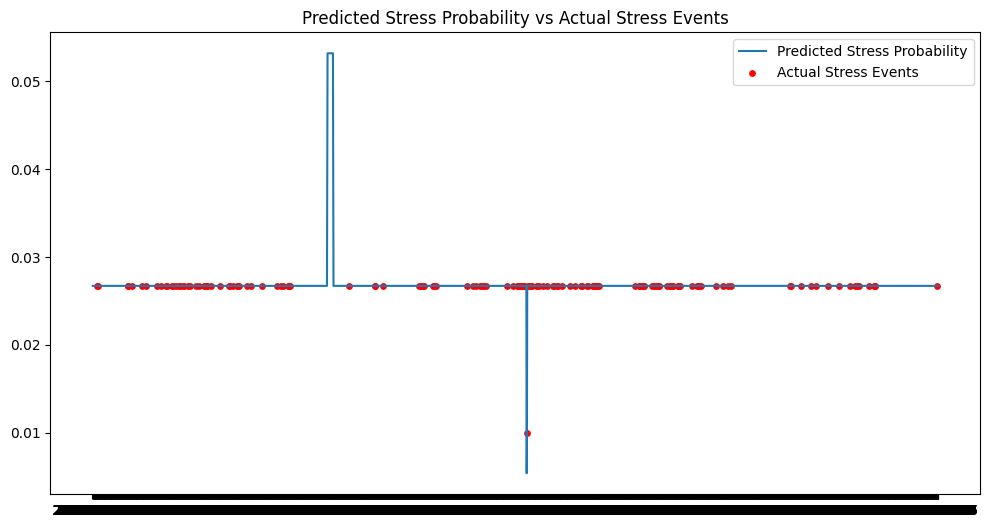

In [ ]:
df.loc[X.index, 'Stress_Prob'] = xgb_model.predict_proba(X)[:,1]

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Stress_Prob'], label="Predicted Stress Probability")
plt.scatter(df['Date'][df['Is_Stress']==1], df['Stress_Prob'][df['Is_Stress']==1],
            color='red', label="Actual Stress Events", s=15)
plt.legend()
plt.title("Predicted Stress Probability vs Actual Stress Events")
plt.show()

In [ ]:
def risk_summary(stress_prob, sector_returns):
    VaR_95 = np.percentile(sector_returns, 5)
    CVaR_95 = sector_returns[sector_returns < VaR_95].mean()
    return {"Stress_Prob": stress_prob, "VaR": VaR_95, "CVaR": CVaR_95}

# Example for Nifty 50
summary = risk_summary(df['Stress_Prob'].iloc[-1], df['Nifty 50'])
print(summary)

{'Stress_Prob': np.float32(0.026715184), 'VaR': np.float64(-0.0142332), 'CVaR': np.float64(-0.023482846666666665)}


In [ ]:
def rebalance_portfolio(weights, stress_prob, threshold=0.6):
    new_weights = weights.copy()

    if stress_prob > threshold:
        # Reduce cyclical sectors
        for cyclical in ['Bank Nifty','Nifty IT','Nifty Auto']:
            if cyclical in new_weights:
                new_weights[cyclical] *= 0.7

        # Increase defensive sectors
        for defensive in ['Nifty Pharma','Nifty FMCG','Gold']:
            if defensive in new_weights:
                new_weights[defensive] *= 1.2

        # Normalize to sum = 1
        total = sum(new_weights.values())
        new_weights = {k:v/total for k,v in new_weights.items()}

    return new_weights

# Example usage
portfolio = {'Bank Nifty':0.3, 'Nifty Pharma':0.2, 'Nifty IT':0.2, 'Nifty FMCG':0.2, 'Gold':0.1}
new_portfolio = rebalance_portfolio(portfolio, df['Stress_Prob'].iloc[-1])
print(new_portfolio)

{'Bank Nifty': 0.3, 'Nifty Pharma': 0.2, 'Nifty IT': 0.2, 'Nifty FMCG': 0.2, 'Gold': 0.1}


In [ ]:
print(df.columns)

Index(['Date', 'Nifty 50', 'Bank Nifty', 'Nifty Pharma', 'Nifty IT',
       'Nifty Auto', 'Nifty FMCG', 'India_VIX', 'Gold', 'Crude_Oil', 'USD_INR',
       'SP500', 'Repo_Rate', 'CPI_Inflation', 'Is_Stress', 'VIX_lag',
       'Repo_lag', 'CPI_lag', 'USD_INR_lag', 'Gold_lag', 'Crude_Oil_lag',
       'SP500_lag', 'Stress_Prob'],
      dtype='object')


In [ ]:
# Predictions only for test set
df.loc[X_test.index, 'Stress_Prob'] = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
# Align df with X
df = df.loc[X.index].copy()

# Now assignment will work
df['Stress_Prob'] = xgb_model.predict_proba(X)[:,1]

In [ ]:
df.loc[X_test.index, 'Stress_Prob'] = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
print("Length of df:", len(df))
print("Length of X:", len(X))

Length of df: 2986
Length of X: 2986


In [ ]:
import numpy as np
import pandas as pd

def sector_risk_table(df, sectors):
    results = []
    for sector in sectors:
        returns = df[sector].dropna()
        VaR_95 = np.percentile(returns, 5)
        CVaR_95 = returns[returns < VaR_95].mean()
        results.append({"Sector": sector, "VaR (95%)": VaR_95, "CVaR (95%)": CVaR_95})
    return pd.DataFrame(results)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 72.9 MB/s eta 0:00:00


2026-03-21 13:02:47.971 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:02:48.205 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-21 13:02:48.206 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:02:48.208 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:02:48.308 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:02:48.359 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:02:48.360 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:02:48.361 Thread 'MainThread': mi

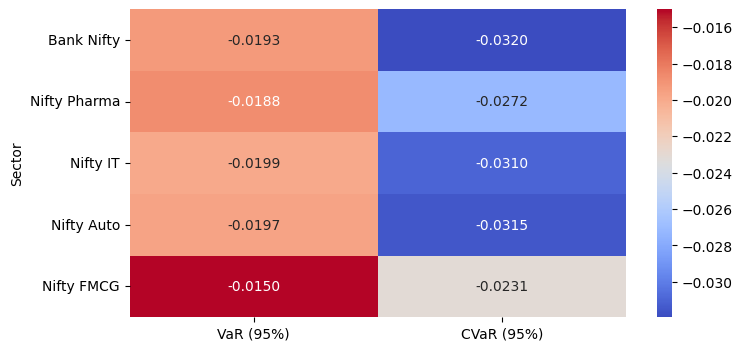

In [ ]:
# Ensure Streamlit is installed. A runtime restart might be needed after first installation.
!pip install streamlit

import streamlit as st
import seaborn as sns
import matplotlib.pyplot as plt

sectors = ['Bank Nifty','Nifty Pharma','Nifty IT','Nifty Auto','Nifty FMCG']

# Assuming 'page' is defined elsewhere in a Streamlit app structure.
# For demonstration, we'll assume a default 'page' or remove the if condition.
page = "Sector Risk" # For demonstration purposes, define 'page'

if page == "Sector Risk":
    st.title("Sector Risk Analysis")

    # Make sure df and sector_risk_table are defined before this cell or accessible globally
    # df is available in the kernel state
    # sector_risk_table is defined in cell EGgA5YfLuNcD

    risk_df = sector_risk_table(df, sectors)
    st.dataframe(risk_df.style.format({"VaR (95%)":"{:.4f}", "CVaR (95%)":"{:.4f}"}))

    # Heatmap for quick visualization
    fig, ax = plt.subplots(figsize=(8,4))
    sns.heatmap(risk_df.set_index("Sector"), annot=True, cmap="coolwarm", fmt=".4f", ax=ax)
    st.pyplot(fig)

In [ ]:
current_prob = df['Stress_Prob'].iloc[-1]

if current_prob > 0.6:
    st.warning(f"High Stress Probability Detected: {current_prob:.2f}")
    st.write("Defensive sectors (Pharma, FMCG, Gold) recommended.")
else:
    st.success(f"Low Stress Probability: {current_prob:.2f}")
    st.write("Normal allocations can be maintained.")

2026-03-21 13:03:17.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:03:17.645 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:03:17.647 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:03:17.648 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:03:17.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:03:17.651 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
def rebalance_portfolio(weights, stress_prob, threshold=0.6):
    new_weights = weights.copy()

    if stress_prob > threshold:
        # Reduce cyclical sectors
        for cyclical in ['Bank Nifty','Nifty IT','Nifty Auto']:
            if cyclical in new_weights:
                new_weights[cyclical] *= 0.7

        # Increase defensive sectors
        for defensive in ['Nifty Pharma','Nifty FMCG','Gold']:
            if defensive in new_weights:
                new_weights[defensive] *= 1.2

        # Normalize to sum = 1
        total = sum(new_weights.values())
        new_weights = {k:v/total for k,v in new_weights.items()}

    return new_weights

In [ ]:
if page == "Portfolio Toolkit":
    st.title("Portfolio Rebalancing Toolkit")
    st.write("Adjust your portfolio weights below:")

    bank = st.slider("Bank Nifty", 0.0, 1.0, 0.3)
    pharma = st.slider("Nifty Pharma", 0.0, 1.0, 0.2)
    it = st.slider("Nifty IT", 0.0, 1.0, 0.2)
    auto = st.slider("Nifty Auto", 0.0, 1.0, 0.1)
    fmcg = st.slider("Nifty FMCG", 0.0, 1.0, 0.1)
    gold = st.slider("Gold", 0.0, 1.0, 0.1)

    portfolio = {
        'Bank Nifty': bank,
        'Nifty Pharma': pharma,
        'Nifty IT': it,
        'Nifty Auto': auto,
        'Nifty FMCG': fmcg,
        'Gold': gold
    }

    stress_prob = df['Stress_Prob'].iloc[-1]  # latest probability
    new_portfolio = rebalance_portfolio(portfolio, stress_prob)

    st.subheader("Original Portfolio")
    st.write(portfolio)

    st.subheader("Rebalanced Portfolio (based on stress probability)")
    st.write(new_portfolio)

    st.info(f"Current Stress Probability: {stress_prob:.2f}")

In [ ]:
import pandas as pd

orig_df = pd.DataFrame.from_dict(portfolio, orient='index', columns=['Original'])
reb_df = pd.DataFrame.from_dict(new_portfolio, orient='index', columns=['Rebalanced'])
combined = pd.concat([orig_df, reb_df], axis=1)

st.bar_chart(combined)

2026-03-21 13:03:24.104 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:03:24.105 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:03:24.106 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importance
importance = xgb_model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns).sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis", ax=ax)
ax.set_title("Feature Importance (XGBoost)")
st.pyplot(fig)

/tmp/ipykernel_2166/2195732609.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis", ax=ax)
2026-03-21 13:03:24.287 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:03:24.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:03:24.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:03:24.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
import joblib
joblib.dump(xgb_model, 'market_stress_model.pkl')
joblib.dump(scaler, 'scaler.pkl')   # Add this

['scaler.pkl']

In [ ]:
model  = joblib.load('market_stress_model.pkl')
scaler = joblib.load('scaler.pkl')

# Define X_new with appropriate column names and example data
# You should replace this with your actual new market data points.
# The columns should match the features used during training.
# For example, let's assume it's a single row of data for prediction.
X_new = pd.DataFrame([[18.0, 5.5, 6.0, 75.0, 1800.0, 70.0, 3900.0, # Current indicators
                       17.5, 5.6, 5.9, 74.5, 1790.0, 71.0, 3850.0]], # Lagged indicators
                     columns=['India_VIX','Repo_Rate','CPI_Inflation','USD_INR','Gold','Crude_Oil','SP500',
                              'VIX_lag','Repo_lag','CPI_lag','USD_INR_lag','Gold_lag','Crude_Oil_lag','SP500_lag'])

X_scaled = scaler.transform(X_new)
predictions = model.predict_proba(X_scaled)[:,1]

In [ ]:
df = df.loc[X.index].copy()
df['Stress_Prob'] = xgb_model.predict_proba(X)[:,1]
df.to_csv('market_stress_analysis_final.csv', index=False)

In [ ]:
from sklearn.metrics import precision_recall_curve

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(recall, precision, marker='.')
ax.set_title("Precision-Recall Curve (XGBoost)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
st.pyplot(fig)

2026-03-21 13:04:35.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:04:36.106 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:04:36.108 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:04:36.110 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
df_test = df.loc[X_test.index].copy()
df_test['Stress_Prob'] = y_prob_xgb

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df_test['Date'], df_test['Stress_Prob'], label="Predicted Stress Probability")
ax.scatter(df_test['Date'][df_test['Is_Stress']==1],
           df_test['Stress_Prob'][df_test['Is_Stress']==1],
           color='red', label="Actual Stress Events", s=15)
ax.legend()
ax.set_title("Backtest: Predicted Stress vs Actual")
st.pyplot(fig)

2026-03-21 13:04:37.529 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:04:49.148 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:04:49.150 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-21 13:04:49.153 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
if page == "Model Insights":
    st.title("Model Insights")
    st.write("Feature Importance, Precision-Recall Curve, Backtest")

    # Feature importance
    st.subheader("Feature Importance")
    st.pyplot(fig)  # from feature importance plot

    # Precision-Recall
    st.subheader("Precision-Recall Curve")
    st.pyplot(fig)  # from PR curve plot

    # Backtest
    st.subheader("Backtest Predictions")
    st.pyplot(fig)  # from backtest chart

In [ ]:
import joblib

# Save the trained XGBoost model
joblib.dump(xgb_model, 'market_stress_model.pkl')

# If you used a scaler, save it too
joblib.dump(scaler, 'scaler.pkl')

# Save your cleaned dataframe for the charts
df.to_csv('deploy_data.csv', index=False)

In [ ]:
# This saves your current data (with the new probability column)
# so the app can read it easily.
df.to_csv('market_stress_analysis_final.csv', index=False)